## IT 720: NLP, Assignment 2

When you submit the assignment, make sure that you:

- add your name to the file name
- shut down the kernel one last time, restart it, and run your code from start to finish.
- leave the output in each cell to allow the grader to see it
- if there is a bug that you cannot resolve, leave the error message in the output cell so the grader can see it

### Rubric for the numbered sections below where you must write your own code, 175 points total
1.  10 points: Train, Valid, Test Split
2.  20 points: BiLSTM
3.  20 points: BiLSTM with Classifier Head
4.  20 points: Fit Encoder
5.  20 points: Visualize Training Loss and Accuracy
6.  20 points: Create Sentence Embeddings
7.  20 points: Define and Train FFClassifier
8.  15 points: Combine Data and Retrain
9.  10 points: Confusion Matrix
10. 20 points: Two UMAP Scatterplots


### Assignment 2 – Neural Sentence Embeddings with BiLSTM + Feedforward Classifier

#### The first 3 code cells are provided to help you get started, as well a few other cells below.

In this assignment, your code will:

- Build a neural **sentence encoder** using a bi‑directional LSTM
- Learn the word (token) embeddings
- Use the encoder to generate **fixed‑dimensional embeddings** for movie reviews.
- Train a **feed‑forward neural network (FFNN)** classifier on top of these embeddings.
- Evaluate performance and conduct **error analysis** on misclassified examples.

This solution notebook contains:

1. Data loading and (minimal) preprocessing  
2. BiLSTM sentence encoder construction and training  
3. Embedding extraction for all reviews  
4. Feed‑forward classifier training
5. Evaluation and confusion matrix  
6. Error analysis with concrete examples


In [13]:
# This cell contains all packages and functions you need to do the assignment.
# You may substitute PyTorch code instead of Keras/Tensorflow, but you would
# have to replace many imports here with similar imports for PyTorch.

import nltk
import os
import random
try:
    import umap
except ImportError:
    print("UMAP not available, will use PCA for visualization instead")
    from sklearn.decomposition import PCA
    umap = None

import matplotlib.pyplot as plt
import numpy             as np
import seaborn           as sns
import tensorflow        as tf


from nltk                    import word_tokenize
from nltk.corpus             import movie_reviews
from sklearn.metrics         import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.callbacks              import EarlyStopping
from tensorflow.keras.layers                 import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models                 import Model, Sequential
from tensorflow.keras.optimizers             import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text     import Tokenizer

print("TensorFlow version:", tf.__version__)


UMAP not available, will use PCA for visualization instead

TensorFlow version: 2.15.0


## Reproducibility and setup

We set random seeds for `numpy`, Python's `random`, and TensorFlow to reduce variance in results.  
Note: in real training, results will still vary slightly across runs and hardware, but this helps.


In [21]:
SEED = 34

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# The next line is for GPU determinism (may not be perfect across all environments)
# If this generates an error, just delete it. It's optional.
os.environ["PYTHONHASHSEED"] = str(SEED)


## Loading the movie reviews corpus

We reuse the same **NLTK `movie_reviews`** dataset as in Assignment 1.

- Each document is a full review.
- Each review is labeled with a **sentiment**: `pos` or `neg`.
- We will:
  - Extract raw tokenized reviews.
  - Convert them into text sequences (space‑joined tokens).
  - Assign integer labels: `0` for negative, `1` for positive.


In [22]:
# Load the movie reviews
nltk.download('movie_reviews')

# movie_reviews.fileids() gives list like ['neg/cv000_29416.txt', 'pos/cv000_29590.txt', ...]
fileids = movie_reviews.fileids()
print("Number of documents:", len(fileids))
print("Example fileid:", fileids[0])

# Extract documents and labels
documents = []
labels    = []    # We will add 0 for negative review and 1 for positive

for fid in fileids:
    # tokens: list of strings
    tokens = movie_reviews.words(fid)
    # join back into a whitespace-separated string
    text = " ".join(tokens)
    documents.append(text)

    # label: 'pos' or 'neg'
    label = movie_reviews.categories(fid)[0]
    labels.append(1 if label == "pos" else 0)

print("\nExample document:")
print(documents[0][:500], "...")
print("\nLabel (0=neg, 1=pos):", labels[0])


[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Kiran\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


Number of documents: 2000
Example fileid: neg/cv000_29416.txt

Example document:
plot : two teen couples go to a church party , drink and then drive . they get into an accident . one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . what ' s the deal ? watch the movie and " sorta " find out . . . critique : a mind - fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . which is what makes this review an even harder one to write , since i generally applaud films which attempt t ...

Label (0=neg, 1=pos): 0


# Your own code will begin here.

## 1. Train/validation/test split

Add your own code to split the dataset into:

- **Train**: for fitting the BiLSTM encoder and the FFNN.
- **Validation**: for early stopping during BiLSTM training.
- **Test**: held‑out data for final evaluation.

Using scikit-learn's train_test_split, create an 80-20 split for training and test data, but then do another 80-20 split on that training data to get a training set with 64% of the original 2000 reviews with 16% of the 2000 held out for validation.

Please create the following variable names in your code for the training, validation and test sets:
- X_train, y_train
- X_val,   y_val
- X_test,  y_test

After you have set the variables print out the shapes of X_train, X_val and X_test

In [24]:
X = np.array(documents)
y = np.array(labels)

# Use X and y to now create your six variables for training, validation and test data.

# First split: train+val vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

# Second split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, random_state=SEED, stratify=y_train_val)

# Print out shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (1280,)
X_val: (320,)
X_test: (400,)
y_train: (1280,)
y_val: (320,)
y_test: (400,)


## Tokenization and integer encoding

We now:

1. Fit a Keras `Tokenizer` on the training text.
2. Convert texts to integer sequences.
3. Pad sequences to a fixed maximum length.


In [29]:
# This cell is provided to you and shows how to create and use a simple
# whole-word based tokenizer using Keras' Tokenizer utility. The Keras
# documentation is not very good regarding tokenizers. However, the following
# HuggingFace page does provide good detail on several approaches to
# tokenization, and is a good supplement to the somewhat limited discussion
# that you can find in Jurafsky and Martin's chapter on 'Words and Tokens'
# https://huggingface.co/docs/transformers/fast_tokenizers

MAX_VOCAB_SIZE = 10000   # This will limit our total vocab size to most frequent 10000 in the data
MAX_SEQ_LEN    = 256     # Truncate/pad to this length so every review is same length
EMBEDDING_DIM  = 128     # Dimensionality of learned token embeddings

# The next line will add '<OOV>' to the list of vocabulary words and assign it the integer 1.
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")

# When fit_on_texts is called, it will find the top 9,999 words by frequency and assign a unique integer to each word.
# Integer 1 has already been assigned to the special vocab token <OOV>, so any word found in the texts
# that is not among those top 9,999 will just get assigned the 1.
tokenizer.fit_on_texts(X_train)

def texts_to_padded_sequences(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return(pad_sequences(seqs, maxlen=MAX_SEQ_LEN, padding='post', truncating='post'))

X_train_seq = texts_to_padded_sequences(X_train)
X_val_seq   = texts_to_padded_sequences(X_val)
X_test_seq  = texts_to_padded_sequences(X_test)

print("Train sequences shape:\t\t",    X_train_seq.shape)
print("Validation sequences shape:\t", X_val_seq.shape)
print("Test sequences shape:\t\t",     X_test_seq.shape)

# Each review has now been converted to a sequence of integers. Remember, 1 represents any low frequency word
# which could be a misspelling or simply a very rare word.
# Let's look at the tokenization of the first review in the training sequences:

print('\nThe tokenization of the first review in X_train_seq is:')
X_train_seq[0]

Train sequences shape:		 (1280, 256)
Validation sequences shape:	 (320, 256)
Test sequences shape:		 (400, 256)

The tokenization of the first review in X_train_seq is:


array([1816,    4,    2,  469,    1, 1115,    2,  209,    9,  360,    1,
       2307,    3,  835, 2108,    5, 6552,    1,  419, 4633, 2367,    4,
         27, 1268, 1283,   11,    7,   10,  375,  974,  205,   33,   11,
          7,   10,  999,    1,   22,    2, 2061,    5,  555,  622,   11,
          7,   10,  151,    1,   52,    2,    1,  151,    3,  113,    4,
          3,  266, 1816, 8282, 3135,    8,    3,    1,  959, 9094,   14,
          3, 1301,    5,    1,  261,    6, 4073,   39,    1, 1449, 3903,
          2,  700,  308,    5,   39,  539,   14,  409,    9,    1,   50,
        216,    2, 6553,    5,  469, 9095, 3904, 6112, 1548,    6,    1,
         18,  409,    9,    2,  850, 1159, 9095, 1060,    2, 1960,    5,
          2,  959,    4, 6113,    1,   12,   18,  715,    7,   10,  511,
       1086,    9,  460,  340,   47,    6,    2,  789,    5,    2, 2554,
        137, 1816, 4634,    8,    6,  271, 1116,   12, 4420,    2, 1817,
          5,    2,   17,    5,  221, 1891,   14,   

## 2. Building the BiLSTM sentence encoder

Build a Keras model that takes a sequence of token IDs and returns a **fixed‑dimensional sentence embedding**
In doing so, the model will also learn embeddings for the tokens.

Architecture:

- Input: integer sequence of length `MAX_SEQ_LEN`.
- Embedding layer: maps tokens to `EMBEDDING_DIM`‑dimensional learned vectors.
- BiLSTM: processes the sequence in both directions.
- We set `return_sequences=False` to get a single vector per sequence.
- A final dense layer to reshape the reviews dimension and add nonlinearity. This has been supplied for you.

The final encoder outputs a sentence embedding vector of reduced dimensionality, i.e. fewer dimensions than output of the biLSTM.

The shrinking of the final sentence embedding is because:
a. Fewer dimensions may result in less overfitting due to the reduced capacity of representation. You will see
   that overfitting may be a huge issue for this assignment, mainly because of the tiny size of the dataset
   
b. A 'bottleneck' of the  dimensionality for the sentence embeddings allows
    you to make changes elsewhere and still arrive at the same final dimensionality
    vis-a-vis the representation capacity of a biLSTM.
    
c. The tanh activation reshapes the embedding space into a bounded, centered region. This often
   makes downstream classifiers behave more predictably


In [26]:
# Build sequential LSTM model in Keras (or PyTorch, if you prefer).
# You can choose your own hyperparameter values, e.g. number of units for the layers,
# names of layers, etc. unless otherwise noted.

# Begin with an Input layer that takes reviews with shape=(MAX_SEQ_LEN,)
encoder_input = Input(shape=(MAX_SEQ_LEN,), name="encoder_input")

# Add an Embedding layer to learn word (token) embeddings
encoder_embedding = Embedding(
    input_dim=MAX_VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_SEQ_LEN,
    name="token_embedding")(encoder_input)

# Add a bidirectional LSTM with return_sequences=False and that outputs 64 dimensions
# in each direction producing 128 dimensions for final LSTM output
encoder_lstm = Bidirectional(LSTM(64, return_sequences=False), name="bilstm")(encoder_embedding)

# Follow the biLSTM with a Dense layer that outputs only 48 dimensions. This is the 'bottleneck' mentioned above.
# This Dense layer should use a 'tanh' activation function.
sentence_embedding = Dense(48, activation="tanh", name="sentence_embedding")(encoder_lstm)

## 3. Training the BiLSTM encoder for sentiment classification

Before we train our biLSTM, we need to give it a supervisory signal for training that is relevant to our task of classifying movie review sentiments. Without that signal, the learned token embeddings will not be able to contribute useful information to the desired task.  Therefore, we will attach a simple classification head to our encoder solely for this purpose. Do not confuse the classification head here with the Feed Forward Classifier that we will create later after we train the encoder.  

To train the encoder, we attach a classification head by simply following the sentence_embedding layer with:
- Dropout layer for regularization, choosing your own value for the dropout rate.
- Dense layer with 1 unit and sigmoid activation for binary sentiment.

Make sure you have saved your entire encoder with its classifer head into a variable called 'biLSTM'.
Compile biLSTM with "binary_crossentropy" for the loss function, the Adam optimizer and metrics=["accuracy"]

Call biLSTM.summary() to see a descrition of your complete encoder. You should see 6 layers in the output:
1. Input
2. Embedding
3. Bidirectional
4. Dense
5. Dropout
6. Dense


In [30]:
dropout_rate = 0.3
x = Dropout(dropout_rate, name="encoder_dropout")(sentence_embedding)
output = Dense(1, activation="sigmoid", name="sentiment_output")(x)

biLSTM = Model(inputs=encoder_input, outputs=output, name="biLSTM_encoder_with_head")
biLSTM.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])
biLSTM.summary()

Model: "biLSTM_encoder_with_head"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_input (InputLayer)  [(None, 256)]             0         
                                                                 
 token_embedding (Embedding  (None, 256, 128)          1280000   
 )                                                               
                                                                 
 bilstm (Bidirectional)      (None, 128)               98816     
                                                                 
 sentence_embedding (Dense)  (None, 48)                6192      
                                                                 
 encoder_dropout (Dropout)   (None, 48)                0         
                                                                 
 sentiment_output (Dense)    (None, 1)                 49        
                                          

## 4. Training with early stopping

We train the model and use `EarlyStopping` on validation loss (`val_loss`) to try to prevent overfitting.
Use `restore_best_weights=True` in the case that early stopping is triggered in order to have the best weights returned.

Save the results of the training into the variable 'history', which we will use
to plot the loss and accuracy curves below.

Key hyperparameters are:

- Batch size
- Number of epochs
- Learning rate (set above for Adam, if you wish to change the default)
- Dropout rate (set above)
- The `patience` for early stopping (i.e. how many epochs with no improvement in validation loss for early stopping)
- Use `verbose=1` if you wish to see the output for each epoch during training.


In [28]:
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)

history = biLSTM.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/20


40/40 [==============================] - 7s 115ms/step - loss: 0.6935 - accuracy: 0.5055 - val_loss: 0.6922 - val_accuracy: 0.5000
Epoch 2/20
40/40 [==============================] - 5s 134ms/step - loss: 0.6513 - accuracy: 0.6766 - val_loss: 0.6784 - val_accuracy: 0.5437
Epoch 3/20
40/40 [==============================] - 5s 130ms/step - loss: 0.3280 - accuracy: 0.8891 - val_loss: 0.8170 - val_accuracy: 0.5750
Epoch 4/20
40/40 [==============================] - 5s 123ms/step - loss: 0.0396 - accuracy: 0.9914 - val_loss: 1.0841 - val_accuracy: 0.5906
Epoch 5/20
40/40 [==============================] - 5s 123ms/step - loss: 0.0096 - accuracy: 0.9992 - val_loss: 1.3342 - val_accuracy: 0.5750
Epoch 5: early stopping


## 5. Visualizing training and validation curves

Using matplotlib, write code for two plots:
1. Training and Validation loss
2. Training and validation accuracy

Each plot should show the epochs on the horizontal axis, the metric on the vertical axis, and a legend that shows a different color for the Training vs. Loss or Accuracy curves.

These plots will be useful to visually display any:
- Underfitting vs overfitting behavior.
- The point at which early stopping kicks in.

Make sure you have saved the results of your model's fit into 'history'

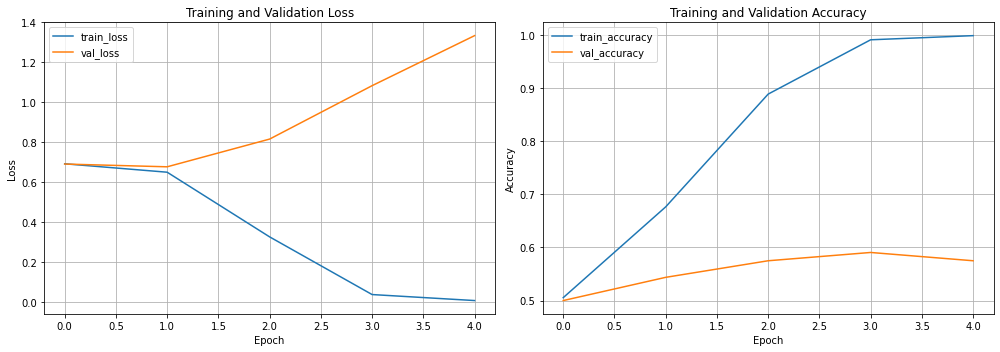

In [33]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Baseline: BiLSTM classifier performance

Before we decouple the encoder and classifier, we can measure how well the full BiLSTM model performs on the test set. This gives a baseline:

- Test accuracy
- Classification report for Precision/recall/F1

Later, we compare this to the FFClassifier trained on learned embeddings.  You can copy/adapt this code later and use it for other models.


In [42]:
# Rebuild the encoder model that outputs the sentence embedding
encoder_only_model = Model(
    inputs=biLSTM.input,
    outputs=biLSTM.get_layer("sentence_embedding").output,
    name="encoder_only_model")

encoder_only_model.summary()

X_train_emb = encoder_only_model.predict(X_train_seq)
X_val_emb = encoder_only_model.predict(X_val_seq)
X_test_emb = encoder_only_model.predict(X_test_seq)

print("X_train_emb shape:", X_train_emb.shape)
print("X_val_emb shape:", X_val_emb.shape)
print("X_test_emb shape:", X_test_emb.shape)

Model: "encoder_only_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_input (InputLayer)  [(None, 256)]             0         
                                                                 
 token_embedding (Embedding  (None, 256, 128)          1280000   
 )                                                               
                                                                 
 bilstm (Bidirectional)      (None, 128)               98816     
                                                                 
 sentence_embedding (Dense)  (None, 48)                6192      
                                                                 
Total params: 1385008 (5.28 MB)
Trainable params: 1385008 (5.28 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
13/13 [==============================] - 1s 27ms/step
X_train_emb shape: (12

## 6. Create sentence embeddings from the trained encoder

Now use the **encoder part only** (up to and including the `sentence_embedding` layer) to generate fixed‑dimensional vectors for each review.

Steps:

1. Extract the encoder inputs from:  `biLSTM.input`
2. Extract the encoder outputs from: `biLSTM.get_layer("sentence_embedding").output`
3. Use the Keras `Model` class to construct a new model from those inputs and outputs, saving the model into a new variable, e.g. maybe you want to use 'encoder_only_model'.
4. Use the 'predict' method of that new model on each of `X_train_seq`, `X_val_seq`, and `X_test_seq` to convert each movie review to a sentence embedding created by the bidirectional LSTM that was previously trained.
5. Store those embeddings into new variables, e.g. X_train_emb for the training reviews.
6. Call `encoder_only_model.summary()` (if that's the name you used) to verify the architecture
7. Print the shapes of the three new variables where you saved the results of Step 5.


In [43]:
input_dim = X_train_emb.shape[1]

ff_input = Input(shape=(input_dim,), name="ff_input")
ff_x = Dense(64, activation="relu", name="ff_dense1")(ff_input)
ff_x = Dropout(0.3, name="ff_dropout")(ff_x)
ff_output = Dense(1, activation="sigmoid", name="ff_output")(ff_x)

ff_classifier = Model(inputs=ff_input, outputs=ff_output, name="FFClassifier")
ff_classifier.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])
ff_classifier.summary()

early_stop_ff = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)

history_ff = ff_classifier.fit(
    X_train_emb,
    y_train,
    validation_data=(X_val_emb, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_ff],
    verbose=1)

# Validation set evaluation

y_val_pred_proba = ff_classifier.predict(X_val_emb)
y_val_pred = (y_val_pred_proba >= 0.5).astype(int)
print("FFClassifier validation accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification report (FFClassifier validation):")
print(classification_report(y_val, y_val_pred, target_names=["neg", "pos"]))

Model: "FFClassifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ff_input (InputLayer)       [(None, 48)]              0         
                                                                 
 ff_dense1 (Dense)           (None, 64)                3136      
                                                                 
 ff_dropout (Dropout)        (None, 64)                0         
                                                                 
 ff_output (Dense)           (None, 1)                 65        
                                                                 
Total params: 3201 (12.50 KB)
Trainable params: 3201 (12.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/30


40/40 [==============================] - 1s 5ms/step - loss: 0.5452 - accuracy: 0.8695 - val_loss: 0.6832 - val_accuracy: 0.5562
Epoch 2/30
40/40 [==============================] - 0s 2ms/step - loss: 0.3544 - accuracy: 0.9000 - val_loss: 0.7358 - val_accuracy: 0.5781
Epoch 3/30
40/40 [==============================] - 0s 2ms/step - loss: 0.2620 - accuracy: 0.9172 - val_loss: 0.7843 - val_accuracy: 0.6062
Epoch 4/30
40/40 [==============================] - 0s 2ms/step - loss: 0.2156 - accuracy: 0.9250 - val_loss: 0.8355 - val_accuracy: 0.6281
Epoch 4: early stopping
10/10 [==============================] - 0s 1ms/step
FFClassifier validation accuracy: 0.55625

Classification report (FFClassifier validation):
              precision    recall  f1-score   support

         neg       0.59      0.36      0.45       160
         pos       0.54      0.75      0.63       160

    accuracy                           0.56       320
   macro avg       0.57      0.56      0.54       320
weighted a

## 7. Define, compile and train a a new feed‑forward neural network (FFClassifier) on embeddings that you just saved.

We now use the Keras to build a new **feed‑forward neural network** with 3 layers:

- Input layer: to accept the sentence embeddings that you just created and saved.
- Hidden layer: a Dense layer with a configurable number of units (your choice) and using "relu".
- Output layer: a Dense layer with 1 unit and the "sigmoid" activation function.

Compile this network as before, define EarlyStopping as before and fit the classifier, again saving it into 'history' or a different history variable of your choice.

Make sure you use the embeddings you saved for the movie reviews for both training and validation.

Predict the sentiment on the VALIDATION set, in a similar way (i.e. using 0.5 as the class threshold) that we predicted the test data the earlier model, but making sure you use the VALIDATION set embeddings that you just saved.

Print the validation data accuracy and classification report, again as you have already done above.

In [44]:
input_dim = X_train_emb.shape[1]

ff_input = Input(shape=(input_dim,), name="ff_input")
ff_x = Dense(64, activation="relu", name="ff_dense1")(ff_input)
ff_x = Dropout(0.3, name="ff_dropout")(ff_x)
ff_output = Dense(1, activation="sigmoid", name="ff_output")(ff_x)

ff_classifier = Model(inputs=ff_input, outputs=ff_output, name="FFClassifier")
ff_classifier.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])
ff_classifier.summary()

early_stop_ff = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)

history_ff = ff_classifier.fit(
    X_train_emb,
    y_train,
    validation_data=(X_val_emb, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_ff],
    verbose=1)

# Validation set evaluation

y_val_pred_proba = ff_classifier.predict(X_val_emb)
y_val_pred = (y_val_pred_proba >= 0.5).astype(int)
print("FFClassifier validation accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification report (FFClassifier validation):")
print(classification_report(y_val, y_val_pred, target_names=["neg", "pos"]))

Model: "FFClassifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ff_input (InputLayer)       [(None, 48)]              0         
                                                                 
 ff_dense1 (Dense)           (None, 64)                3136      
                                                                 
 ff_dropout (Dropout)        (None, 64)                0         
                                                                 
 ff_output (Dense)           (None, 1)                 65        
                                                                 
Total params: 3201 (12.50 KB)
Trainable params: 3201 (12.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/30
40/40 [==============================] - 1s 5ms/step - loss: 0.5567 - accuracy: 0.8305 - val_loss: 0.6797 - val_accuracy: 0.5469
Epoch 2/30
4

## 8. Final training on train+validation and evaluation on test

1. Stack the training and validation embeddings, i.e combine them into a single set of data.
2. As you did near the beginning, create a new split of this data using train_test_split to create a new 90% split for training and 10% for validation, saving each into new variable names.
3. Redefine and Retrain the FFClassifier on these training and validation datasets.
4. Evaluate this final model on predictions for the held‑out test set, i.e. `X_test_emb` if that is the variable name you used for the test embedding data.
5. Print your final accuracy and classifcation report.

This gives us the final performance of the **BiLSTM embeddings + FFNN classifier** pipeline.


In [45]:
# Create a larger training set by stacking the train and validation embeddings
X_train_val_emb = np.vstack([X_train_emb, X_val_emb])
y_train_val_full = np.concatenate([y_train, y_val])

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_val_emb, y_train_val_full, test_size=0.10, random_state=SEED, stratify=y_train_val_full)

final_input = Input(shape=(X_train_final.shape[1],), name="final_input")
final_x = Dense(64, activation="relu")(final_input)
final_x = Dropout(0.3)(final_x)
final_output = Dense(1, activation="sigmoid")(final_x)

final_classifier = Model(inputs=final_input, outputs=final_output, name="final_FFClassifier")
final_classifier.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])
final_classifier.summary()

early_stop_final = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)
history_final = final_classifier.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_final],
    verbose=1)

y_test_pred_proba = final_classifier.predict(X_test_emb)
y_test_pred = (y_test_pred_proba >= 0.5).astype(int)
print("Final FFClassifier test accuracy:", accuracy_score(y_test, y_test_pred))
print("\nFinal classification report:")
print(classification_report(y_test, y_test_pred, target_names=["neg", "pos"]))

Model: "final_FFClassifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 final_input (InputLayer)    [(None, 48)]              0         
                                                                 
 dense_2 (Dense)             (None, 64)                3136      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 3201 (12.50 KB)
Trainable params: 3201 (12.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Epoch 1/30
45/45 [==============================] - 1s 4ms/step - loss: 0.5334 - accuracy: 0.8236 - val_loss: 0.4668 - val_accuracy: 0.8000
Epoch 2/30
45/45 [==============================] - 0s 2ms/step - loss: 0.4029 - accuracy: 0.8424 - val_loss: 0.3875 - val_accuracy: 0.8500
Epoch 3/30
45/45 [==============================] - 0s 2ms/step - loss: 0.3451 - accuracy: 0.8632 - val_loss: 0.3546 - val_accuracy: 0.8500
Epoch 4/30
45/45 [==============================] - 0s 2ms/step - loss: 0.3281 - accuracy: 0.8736 - val_loss: 0.3468 - val_accuracy: 0.8500
Epoch 5/30
45/45 [==============================] - 0s 2ms/step - loss: 0.3237 - accuracy: 0.8743 - val_loss: 0.3439 - val_accuracy: 0.8562
Epoch 6/30
45/45 [==============================] - 0s 2ms/step - loss: 0.3166 - accuracy: 0.8771 - val_loss: 0.3421 - val_accuracy: 0.8500
Epoch 7/30
45/45 [==============================] - 0s 2ms/step - loss: 0.3194 - accuracy: 0.8792 - val_loss: 0.3414 - val_accuracy: 0.8500
Epoch 8/30
45/45 [==

## 9. Confusion matrix for the Final classifier

Using matplotlib (or just Seaborn's `heatmap`) plot a confusion matrix on that test data to show:
- Which class is harder to predict.
- Whether the model is biased toward positive or negative predictions.


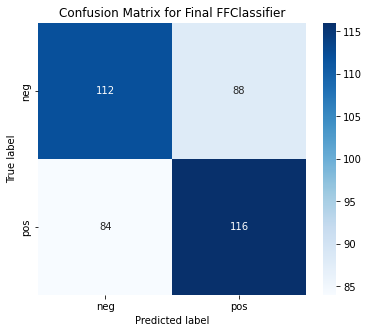

True negatives: 112
False positives: 88
False negatives: 84
True positives: 116


In [46]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix for Final FFClassifier")
plt.show()

if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print("True negatives:", tn)
    print("False positives:", fp)
    print("False negatives:", fn)
    print("True positives:", tp)

## Error analysis: inspecting misclassified reviews

We now examine some **false positives** and **false negatives** to understand:

- Which linguistic phenomena confuse the model.
- How the representation (BiLSTM embeddings) might fail.
- How data sparsity, sarcasm, negation, etc. show up in errors.

I am giving you this cell.


In [47]:
# Identify misclassified indices

y_test_pred = y_test_pred.ravel()
misclassified_indices = np.where(y_test != y_test_pred.ravel())[0]
print('Misclassified indices:\n', misclassified_indices)

print("\nNumber of misclassified examples:", len(misclassified_indices))

# Helper function to print a few examples
def show_misclassified_examples(X_text, y_true, y_pred, indices, n=5, truncated_text=True):
    selected = np.random.choice(indices, size=min(n, len(indices)), replace=False)
    for idx in selected:
        print("="*80)
        print(f"Index: {idx}")
        print(f"True label: {y_true[idx]} ({'pos' if y_true[idx]==1 else 'neg'})")
        print(f"Predicted label: {y_pred[idx]} ({'pos' if y_pred[idx]==1 else 'neg'})")

        if truncated_text:
            print("\nReview text (truncated to 800 chars):\n")
            print(X_text[idx][:800])
        else:
            print("\nReview full text:\n")
            print(X_text[idx])
        print("\n")

truncated_text = True  # Truncate reviews to first 800 characters
num_reviews    = 10     # Display this many reviews
show_misclassified_examples(X_test, y_test, y_test_pred, misclassified_indices,
                            n=num_reviews, truncated_text=truncated_text)


Misclassified indices:
 [  4   8   9  10  14  16  17  21  23  26  27  29  31  39  40  42  43  45
  46  47  48  54  55  56  57  60  62  63  64  65  69  70  71  73  74  76
  83  84  85  86  89  91  92  97  99 101 104 107 110 112 113 117 122 125
 126 129 134 135 136 138 144 145 147 149 152 153 160 161 164 166 168 169
 172 174 175 176 177 181 190 191 194 197 198 199 200 201 202 203 204 205
 214 215 216 218 220 222 227 230 233 234 235 236 237 244 245 246 247 248
 253 254 255 257 258 259 261 263 264 269 270 271 274 275 277 280 281 284
 286 288 294 300 301 302 303 304 305 306 307 308 310 311 314 315 328 331
 332 335 339 340 344 348 349 353 354 356 359 364 367 368 370 371 372 373
 377 379 380 383 386 388 389 393 394 396]

Number of misclassified examples: 172
Index: 300
True label: 1 (pos)
Predicted label: 0 (neg)

Review text (truncated to 800 chars):

a group of high school kids mix up with a group of hip - hop artists as a documentarian strives to discover why today ' s youth seem attracted

### 10. Use UMAP (imported at the beginning) to reduce the dimensionality of the test embeddings and plot them in 2 dimensions.

Individual instructions for each code cell below:
1. Print shape of test embeddings and accuracy score of the test data from Step 8 above.
2. Define UMAP model to reduce X_test_emb (if that was your variable for the test embeddings) to 2 dimensions. Use 'cosine' as the metric, your own values  for n_neighbors, min_dist, and random_state. Call fit_transform method on the X test embeddings, and save result in a variable.  Print the new shape, which should be (400, 2).
3. Create scatterplot of the ground truth labels (i.e. y_test) in the 2 dimensions with labeled axes, title, and legend. Color the plotted points by negative or positive sentiment.
4. Create similar scatterplot to display plotted points that are either correct or incorrect predictions (You can use `y_test == y_test_pred` to get those)


In [38]:
print("X_test_emb shape:", X_test_emb.shape)
print("Final test accuracy:", accuracy_score(y_test, y_test_pred))

X_test_emb shape: (400, 48)
Final test accuracy: 0.5725


In [48]:
if umap is not None:
    umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
    X_test_umap = umap_model.fit_transform(X_test_emb)
else:
    pca_model = PCA(n_components=2, random_state=SEED)
    X_test_umap = pca_model.fit_transform(X_test_emb)
print("UMAP/PCA reduced shape:", X_test_umap.shape)

UMAP/PCA reduced shape: (400, 2)


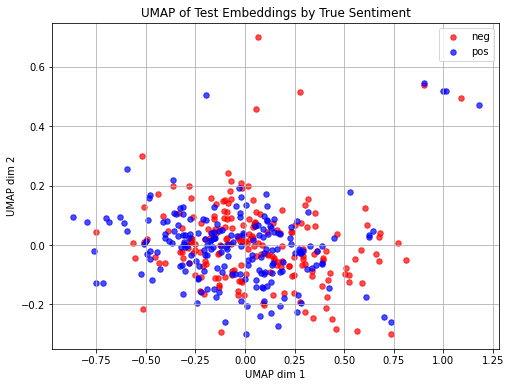

In [40]:
plt.figure(figsize=(8, 6))
for label, color, label_name in [(0, "red", "neg"), (1, "blue", "pos")]:
    mask = (y_test == label)
    plt.scatter(X_test_umap[mask, 0], X_test_umap[mask, 1], c=color, label=label_name, alpha=0.7, s=30)
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.title("UMAP of Test Embeddings by True Sentiment")
plt.legend()
plt.grid(True)
plt.show()

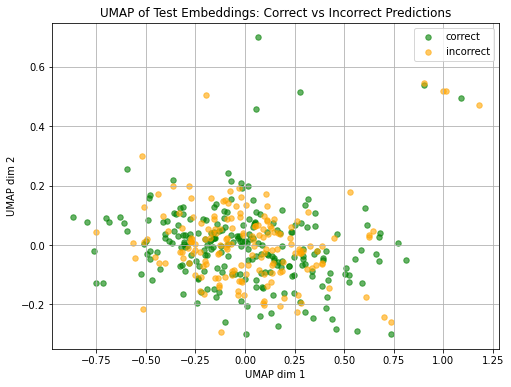

In [49]:
correct = (y_test == y_test_pred.ravel())
plt.figure(figsize=(8, 6))
plt.scatter(X_test_umap[correct, 0], X_test_umap[correct, 1], c="green", label="correct", alpha=0.6, s=30)
plt.scatter(X_test_umap[~correct, 0], X_test_umap[~correct, 1], c="orange", label="incorrect", alpha=0.6, s=30)
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.title("UMAP of Test Embeddings: Correct vs Incorrect Predictions")
plt.legend()
plt.grid(True)
plt.show()

Notice how the correct/incorrect predictions are  as thoroughtly mixed over the embedding space as the ground truth.

This is because:

- Only 2000 reviews total
- Reviews are long, messy, and full of mixed sentiment
- Many reviews contain both praise and criticism
- The writing style varies wildly (sarcasm, rhetorical questions, plot summary)
- Labels are sometimes ambiguous or borderline

#### Some topics for further thought.

1. **Reducing overfitting:**
   - Yaser Abu-Mostafa of CalTech says that learning how to deal with overfitting is what separates amateurs from professionals.
   - If your model above seems to be overfitting, what do you think are the causes and how would you procees to reduce overfitting?

2. **Embeddings as features:**
   - In Assignment 1, you used N‑gram counts or TF–IDF as features.
   - Here, you used **neural sentence embeddings**.
   - In what sense are these embeddings "just another kind of feature"?  
     In what sense are they fundamentally different?

3. **Error patterns:**
   - Look at some false positives and false negatives.
   - What linguistic patterns seem especially hard for the model?
   - How might you extend the model to handle these cases better (without jumping to Transformers yet)?

4. **Bias–variance and data limitations:**
   - How might model capacity (e.g., size of the BiLSTM or FFClassifier) affect underfitting vs overfitting here?
   - If you had access to more data, what changes would you expect in performance and error patterns?


In [50]:
# End of assignment notebook